In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data paths
DATA_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'

print("✅ All imports ready")
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

✅ All imports ready
Libraries loaded successfully


In [3]:
# Load all three main files
sales = pd.read_csv('../data/raw/sales_train_evaluation.csv')
calendar = pd.read_csv('../data/raw/calendar.csv')
prices = pd.read_csv('../data/raw/sell_prices.csv')

print("=== SALES DATA ===")
print(f"Shape: {sales.shape}")
print(f"Rows: {sales.shape[0]:,} | Columns: {sales.shape[1]:,}")
print()
print("=== CALENDAR DATA ===")
print(f"Shape: {calendar.shape}")
print()
print("=== PRICES DATA ===")
print(f"Shape: {prices.shape}")

=== SALES DATA ===
Shape: (30490, 1947)
Rows: 30,490 | Columns: 1,947

=== CALENDAR DATA ===
Shape: (1969, 14)

=== PRICES DATA ===
Shape: (6841121, 4)


In [4]:
# See first few rows
print("First 3 rows of sales data:")
sales.head(3)

First 3 rows of sales data:


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


In [5]:
# Key columns
print("ID columns:")
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
print(sales[id_cols].head(10))

print(f"\nNumber of unique items: {sales['item_id'].nunique():,}")
print(f"Number of unique stores: {sales['store_id'].nunique()}")
print(f"Number of unique categories: {sales['cat_id'].nunique()}")
print(f"Categories: {sales['cat_id'].unique()}")
print(f"States: {sales['state_id'].unique()}")
print(f"Number of day columns: {len([c for c in sales.columns if c.startswith('d_')])}")

ID columns:
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   
5  HOBBIES_1_006_CA_1_evaluation  HOBBIES_1_006  HOBBIES_1  HOBBIES     CA_1   
6  HOBBIES_1_007_CA_1_evaluation  HOBBIES_1_007  HOBBIES_1  HOBBIES     CA_1   
7  HOBBIES_1_008_CA_1_evaluation  HOBBIES_1_008  HOBBIES_1  HOBBIES     CA_1   
8  HOBBIES_1_009_CA_1_evaluation  HOBBIES_1_009  HOBBIES_1  HOBBIES     CA_1   
9  HOBBIES_1_010_CA_1_evaluation  HOBBIES_1_010  HOBBIES_1  HOBBIES     CA_1   

  state_id  
0       CA  
1       CA  
2       CA  
3       CA  
4       CA  
5       CA  
6       CA  
7  

In [ ]:
print("Calendar data:")
print(calendar.head(10))
print(f"\nDate range: {calendar['date'].min()} to {calendar['date'].max()}")
print(f"Total days: {len(calendar)}")
print(f"\nEvent types: {calendar['event_type_1'].dropna().unique()}")

Calendar data:
         date  wm_yr_wk    weekday  wday  month  year     d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011   d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011   d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011   d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011   d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011   d_5          NaN   
5  2011-02-03     11101   Thursday     6      2  2011   d_6          NaN   
6  2011-02-04     11101     Friday     7      2  2011   d_7          NaN   
7  2011-02-05     11102   Saturday     1      2  2011   d_8          NaN   
8  2011-02-06     11102     Sunday     2      2  2011   d_9    SuperBowl   
9  2011-02-07     11102     Monday     3      2  2011  d_10          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  
1       

In [ ]:
STORE = 'CA_1'      # California store 1
CATEGORY = 'FOODS'  # Food products

# Filter
subset = sales[
    (sales['store_id'] == STORE) &
    (sales['cat_id'] == CATEGORY)
].copy()

print(f"Working with: {STORE} | {CATEGORY}")
print(f"Number of items: {len(subset)}")
print(f"Shape: {subset.shape}")

Working with: CA_1 | FOODS
Number of items: 1437
Shape: (1437, 1947)


In [ ]:
# The data is in wide format (each day is a column) - converting to long format (one row per day per item)

# Get day columns
day_cols = [c for c in subset.columns if c.startswith('d_')]

# Melt to long format
subset_long = subset.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

# Merge with calendar to get actual dates
subset_long = subset_long.merge(
    calendar[['d', 'date', 'wday', 'month', 'year',
              'event_name_1', 'event_type_1']],
    on='d',
    how='left'
)

# Convert date to datetime
subset_long['date'] = pd.to_datetime(subset_long['date'])

print(f"Long format shape: {subset_long.shape}")
print(f"\nFirst few rows:")
subset_long.head()

Long format shape: (2789217, 14)

First few rows:


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,month,year,event_name_1,event_type_1
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,1,1,2011,NaN,NaN
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,1,1,2011,NaN,NaN
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,1,1,2011,NaN,NaN
3,FOODS_1_004_CA_1_evaluation,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,1,1,2011,NaN,NaN
4,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,1,1,2011,NaN,NaN


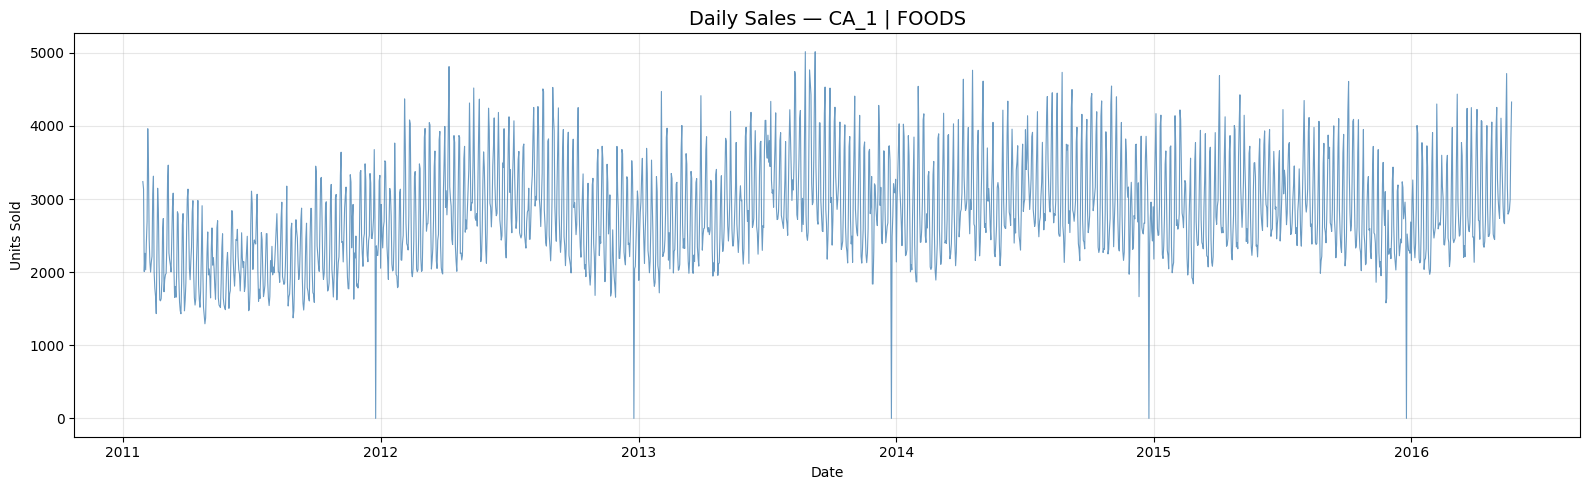


Basic statistics:
count    1941.0
mean     2819.0
std       701.4
min         0.0
25%      2332.0
50%      2717.0
75%      3269.0
max      5016.0
Name: sales, dtype: float64


In [ ]:
# Total daily sales for this store/category
daily_sales = (subset_long
    .groupby('date')['sales']
    .sum()
    .reset_index()
)

# Plot
plt.figure(figsize=(16, 5))
plt.plot(daily_sales['date'], daily_sales['sales'],
         linewidth=0.8, color='steelblue', alpha=0.8)
plt.title(f'Daily Sales — {STORE} | {CATEGORY}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBasic statistics:")
print(daily_sales['sales'].describe().round(1))

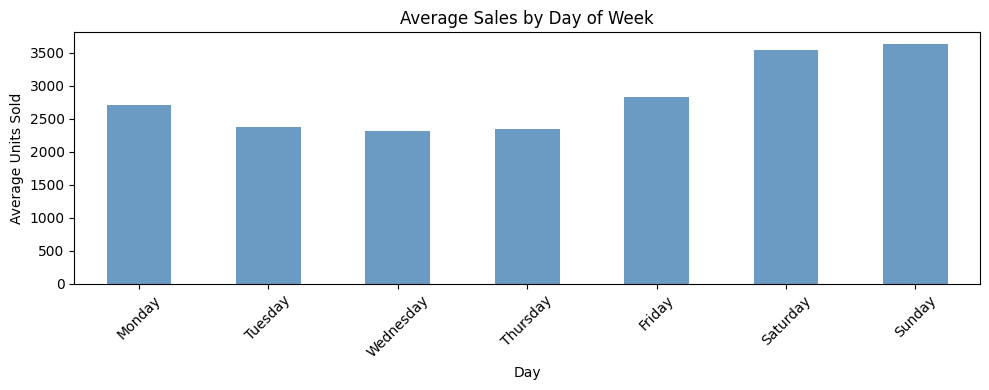

In [ ]:
# Sales by day of week
daily_sales_with_features = daily_sales.copy()
daily_sales_with_features['day_of_week'] = daily_sales['date'].dt.day_name()
daily_sales_with_features['month'] = daily_sales['date'].dt.month
daily_sales_with_features['year'] = daily_sales['date'].dt.year

# Day of week pattern
dow_sales = (daily_sales_with_features
    .groupby('day_of_week')['sales']
    .mean()
    .reindex(['Monday', 'Tuesday', 'Wednesday',
              'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

plt.figure(figsize=(10, 4))
dow_sales.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Average Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save
import os
os.makedirs('../data/processed', exist_ok=True)

daily_sales.to_csv('../data/processed/daily_sales_CA1_FOODS.csv',
                   index=False)
subset_long.to_csv('../data/processed/subset_long_CA1_FOODS.csv',
                   index=False)

print("Data saved to data/processed/")
print(f"Daily sales: {len(daily_sales):,} rows")
print(f"Item level: {len(subset_long):,} rows")

Data saved to data/processed/
Daily sales: 1,941 rows
Item level: 2,789,217 rows
